# 5-Qubit Xmon Processor Layout (Qiskit Metal)

This notebook reconstructs the **planar layout** of the five-qubit Josephson processor demonstrated by Barends, Kelly, Martinis *et al.* (*Nature*-style preprint: *Logic gates at the surface code threshold*). That device placed five **Xmon** (cross-shaped transmon) qubits in a **linear array with nearest-neighbour capacitive coupling**, and used a single multiplexed readout feedline plus per-qubit XY (microwave) and Z (flux) control.

**Paper architecture (Fig. 1) — design intent we mirror here**

| Function | Paper choice | Why it matters |
|---|---|---|
| Qubit | Xmon / cross-shaped transmon | Four arms give **nodal connectivity**: coupling, readout, and control on separate legs without crowding the island |
| Topology | Linear chain Q0–Q4 | First step toward a surface-code lattice; only nearest-neighbour gates needed |
| Coupling | Direct capacitive, $g/2\pi \approx 30\,\mathrm{MHz}$ | Strong enough for ~40 ns CZ near resonance; ~0.3 MHz residual at idle when qubits are detuned (~800 MHz) |
| Idle frequencies | Alternating ~5.5 / 4.7 GHz | Suppresses idle ZZ while allowing fast CZ when brought near resonance |
| Readout | Dispersive resonators, **frequency-domain multiplexed** on one CPW | Simultaneous multi-qubit measurement without one feedline per qubit |
| Control | Capacitive XY drive + inductive Z (flux) | Microwaves for $X$/$Y$; flux bias for frequency tuning / CZ trajectories |

**Scope of this notebook:** geometry and routing in Qiskit Metal → GDS. Frequencies, $g$, and fidelities from the paper are **targets for later EM / Hamiltonian analysis**, not set by Metal alone.


In [2]:
%load_ext autoreload
%autoreload 2
%config IPCompleter.greedy = True
%matplotlib inline
%config Completer.use_jedi = False
%config InlineBackend.figure_format = 'svg'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Environment and design substrate

We enable Metal headless mode (no GUI), import the Xmon-style qubit (`TransmonCrossFL` = cross + flux line), readout couplers, CPW routers, and launchpads, then create a **planar chip**.

The substrate is set to **6 × 6 mm**, giving room for:

- a linear qubit array near chip center,
- meandered readout resonators and a Purcell / feedline path above the qubits,
- wirebond launchpads on all four edges for XY, Z, and multiplexed readout I/O.

This matches the paper’s integrated-circuit picture: Al on sapphire, control pads at the perimeter, qubits and resonators in the interior.


In [3]:
import os
os.environ['QISKIT_METAL_HEADLESS'] = 'True'

import numpy as np


import qiskit_metal as metal
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.qubits.transmon_cross import TransmonCross
from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.framed_path import RouteFramed
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.lumped.cap_n_interdigital import CapNInterdigital

import matplotlib.pyplot as plt
from qiskit_metal.renderers.renderer_mpl.mpl_renderer import QMplRenderer

# Instantiate Design
design = designs.DesignPlanar()
design.chips.main.size.size_x = '6.0mm'
design.chips.main.size.size_y = '6.0mm'

print("Design initialized with a 6x6 mm substrate.")

Design initialized with a 6x6 mm substrate.


## Qubits: linear Xmon array with flux and XY ports

### Paper → layout mapping

In the experiment, five cross-shaped devices sit in a **horizontal linear array**. Each cross arm is reserved for a different role (Fig. 1b):

- **East–west arms** → nearest-neighbour capacitive coupling to adjacent qubits  
- **North arm** → capacitive coupling to that qubit’s readout resonator  
- **South / dedicated pads** → microwave (XY) drive  
- **Flux line (Z)** → inductive coupling into the SQUID for frequency control  

We use `TransmonCrossFL` so each qubit ships with a built-in **flux-line pin** (`flux_line`) for Z routing. An `OpenToGround` pad south of each qubit acts as the **XY coupling capacitor** (Metal does not always expose a dedicated XY pin on this component).

### Key geometric choices in this cell

| Parameter | Value | Design rationale |
|---|---|---|
| `qubit_pitch` | 0.45 mm | Sets capacitive nearest-neighbour $g$; paper target ~30 MHz (tune via pitch / arm length / gap with EM) |
| `cross_width` / `cross_length` / `cross_gap` | 30 / 190 / 50 µm | Defines Xmon capacitance and arm length → $E_C$ / charging energy and coupling lever arms |
| `make_fl=True` + `fl_options` | narrow T-shaped flux line | Inductive Z control with small footprint; gap/width set mutual inductance and microwave leakage |
| Readout claw on north (`connector_location='90'`) | claw ~40 µm | Dispersive coupling $g_r$ to the readout resonator; claw size trades readout speed vs Purcell-limited $T_1$ |
| XY `OpenToGround` at `(x−0.1, −0.18)` mm | 10 µm center / 6 µm gap | Local capacitive drive port; keep far enough from Z line to limit crosstalk |

**Note:** Alternating idle frequencies (paper Table S1: ~5.8 / 5.2 / 5.8 / 5.1 / 5.7 GHz at sweet spot) are **not** coded here—they come from junction $E_J$ and flux bias. The layout only provides the **tunable** Xmons and control wiring those biases will use.


In [4]:
design.delete_all_components()
design.overwrite_enabled = True
qubit_pitch = 0.45  # mm pitch
qubits = []
xy_pads = []
for i in range(5):
    x_pos = (i - 2) * qubit_pitch
    q = TransmonCrossFL(design, f'Q{i}', options=dict(
        pos_x=f'{x_pos}mm',
        pos_y='0.0mm',
        orientation='0',
        cross_width='30um',
        cross_length='190um',
        cross_gap='50um',
        make_fl =True,
        fl_options = dict(
            t_gap='3um', 
            t_inductive_gap='3um', 
            t_offset='0um', 
            t_top='15um', 
            t_width='5um',
        ),
        connection_pads=dict(
            readout = dict(
                connector_type='0', 
                claw_length='40um', 
                ground_spacing='5um', 
                claw_width='10um', 
                claw_gap='6um', 
                connector_location='90' # North arm
            ),
        )
    ))
    qubits.append(q)

# 1. Place manual XY coupling pads (orientation = 90)

    xy_pad = OpenToGround(design, f'XY_pad_{i}', options=dict(
        pos_x=f'{x_pos - 0.1}mm',
        pos_y='-0.18mm',
        orientation='90',
        width='10um',
        gap='6um',
        termination_gap='6um'
    ))
    xy_pads.append(xy_pad)

print("XY pads placed!")
print("Placed qubits Q0, Q1, Q2, Q3, Q4!")

XY pads placed!
Placed qubits Q0, Q1, Q2, Q3, Q4!


In [5]:
xy_pads

[name:    XY_pad_0
 class:   OpenToGround          
 options: 
   'pos_x'             : '-1.0mm',                     
   'pos_y'             : '-0.18mm',                    
   'orientation'       : '90',                         
   'chip'              : 'main',                       
   'layer'             : '1',                          
   'width'             : '10um',                       
   'gap'               : '6um',                        
   'termination_gap'   : '6um',                        
 module:  qiskit_metal.qlibrary.terminations.open_to_ground
 id:      2,
 name:    XY_pad_1
 class:   OpenToGround          
 options: 
   'pos_x'             : '-0.55mm',                    
   'pos_y'             : '-0.18mm',                    
   'orientation'       : '90',                         
   'chip'              : 'main',                       
   'layer'             : '1',                          
   'width'             : '10um',                       
   'gap'         

## Intermediate render — qubit array only

Quick visual check that Q0–Q4 are centered, equally spaced, and that each has a north readout claw and a south XY pad before adding resonators and long control routes.


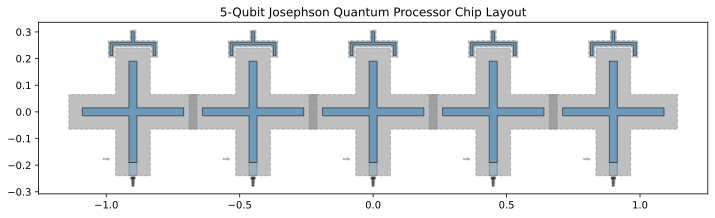

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))
renderer = QMplRenderer(design, logger=design.logger)
renderer.render(ax)

ax.autoscale()
ax.set_aspect('equal')
plt.title("5-Qubit Josephson Quantum Processor Chip Layout")
plt.show()

## Multiplexed readout feedline (Purcell / bus waveguide)

### Paper architecture

The processor reads all five qubits through **one coplanar waveguide** using **frequency-domain multiplexing**: each qubit couples to its own resonator at a distinct frequency; the resonators couple weakly into a shared feedline (Fig. 1a–b, blue path). That feedline connects to readout-in / readout-out ports at the chip edge.

### What this cell builds

1. **`CoupledLineTee` (CLT0–CLT4)** at $y = 1.5\,\mathrm{mm}$ — directional couplers / tee junctions that tap each resonator into the prime (feed) line. `coupling_length` / `coupling_space` set the resonator–feed coupling $\kappa$ (and thus readout bandwidth).
2. **Wirebond launchpads** on all four sides — pad farm for readout I/O and (later) XY/Z control. Spacing (~1.5 mm) mirrors typical probe / bonding pitch.
3. **`CapNInterdigital` input/output caps** — DC blocks / coupling capacitors on the feedline path (common for filtering and matching into the multiplexed line).
4. **Prime-line routing** — `RouteStraight` / `RouteAnchors` stitch `LP_W3 → Cap_input → CLT0…CLT4 → Cap_output → LP_N1`, forming the shared measurement bus.

The printed **Purcell filter length** is a running geometric total along that bus; use it when sizing filter resonances relative to the readout band. Exact Purcell/feed matching should be verified with HFSS / Sonnet before fab.


In [7]:
# Let's track the length of Purcell filter starting from directional couplers.
total_purcell_length_mm = 0
# 1. Place CoupledLineTee couplers at y = 1.5 mm
couplers = []
for i in range(5):
    x_pos = (i - 2) * qubit_pitch
    clt = CoupledLineTee(design, f'CLT{i}', options=dict(
        pos_x=f'{x_pos}mm',
        pos_y='1.5mm',
        orientation='0',
        coupling_length='200um',
        coupling_space='4um'
    ))
    couplers.append(clt)
    total_purcell_length_mm += 0.2

# 2. Place Launchpads on all 4 sides (centered and 1.5 mm apart)
# Left side
lp_w1 = LaunchpadWirebond(design, 'LP_W1', options=dict(pos_x='-2.8mm', pos_y='-1.5mm', orientation='0'))
lp_w2 = LaunchpadWirebond(design, 'LP_W2', options=dict(pos_x='-2.8mm', pos_y='0.0mm', orientation='0'))
lp_w3 = LaunchpadWirebond(design, 'LP_W3', options=dict(pos_x='-2.8mm', pos_y='1.5mm', orientation='0'))

# Right side
lp_e1 = LaunchpadWirebond(design, 'LP_E1', options=dict(pos_x='2.8mm', pos_y='-1.5mm', orientation='180'))
lp_e2 = LaunchpadWirebond(design, 'LP_E2', options=dict(pos_x='2.8mm', pos_y='0.0mm', orientation='180'))
lp_e3 = LaunchpadWirebond(design, 'LP_E3', options=dict(pos_x='2.8mm', pos_y='1.5mm', orientation='180'))

# Bottom side
lp_s1 = LaunchpadWirebond(design, 'LP_S1', options=dict(pos_x='-1.5mm', pos_y='-2.8mm', orientation='90'))
lp_s2 = LaunchpadWirebond(design, 'LP_S2', options=dict(pos_x='0.0mm', pos_y='-2.8mm', orientation='90'))
lp_s3 = LaunchpadWirebond(design, 'LP_S3', options=dict(pos_x='1.5mm', pos_y='-2.8mm', orientation='90'))

# Top side
lp_n1 = LaunchpadWirebond(design, 'LP_N1', options=dict(pos_x='-1.5mm', pos_y='2.8mm', orientation='270'))
lp_n2 = LaunchpadWirebond(design, 'LP_N2', options=dict(pos_x='0.0mm', pos_y='2.8mm', orientation='270'))
lp_n3 = LaunchpadWirebond(design, 'LP_N3', options=dict(pos_x='1.5mm', pos_y='2.8mm', orientation='270'))

# 3. Place CapNInterdigital components for the feedline (length ~ 9mm)
cap_in = CapNInterdigital(design, 'Cap_input', options=dict(pos_x='-2.4mm', pos_y='1.5mm', orientation='270'))
cap_out = CapNInterdigital(design, 'Cap_output', options=dict(pos_x='-1mm', pos_y='2.1mm', orientation='90'))

print("Placed all launchpads and CapNInterdigital components!")

# 4. Connect readout feedline (bus waveguide)
# Connect LP_W3 to Cap_input
RouteStraight(design, 'Feed_in_lp', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='LP_W3', pin='tie'),
        end_pin=dict(component='Cap_input', pin='south_end')
    )
))

# Connect Cap_input to CLT0
purcell_left = RouteStraight(design, 'Feed_in_clt', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='Cap_input', pin='north_end'),
        end_pin=dict(component='CLT0', pin='prime_start')
    )
))
total_purcell_length_mm += purcell_left.length
for i in range(4):
    feed_i =  RouteStraight(design, f'Feed_mid_{i}', options=dict(
        pin_inputs=dict(
            start_pin=dict(component=f'CLT{i}', pin='prime_end'),
            end_pin=dict(component=f'CLT{i+1}', pin='prime_start')
          )
    ))
    total_purcell_length_mm += feed_i.length
# Connect CLT4 to Cap_output via bend and straight
purcell_right = RouteAnchors(design, 'Feed_out_clt', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='CLT4', pin='prime_end'),
        end_pin=dict(component='Cap_output', pin='north_end')
    ),

    anchors=Dict({0: (1.7, 1.5), 1: (1.7,1.8), 2: (-2.4, 1.8), }),
    fillet='100um',
    advanced=Dict(avoid_collision=False)
))
total_purcell_length_mm += purcell_right.length
# Connect Cap_output to LP_N1
RouteAnchors(design, 'Feed_out_lp', options=dict(
    pin_inputs=dict(
        start_pin=dict(component='Cap_output', pin='south_end'),
        end_pin=dict(component='LP_N1', pin='tie')
    ),
    lead = Dict(start_straight = '200um',end_straight='100um'),
    # anchors=Dict({0: (-1.4, 2.1), 1: (-1, 2.5), 2: (-1, 2.5)}),
    fillet='20um',
    advanced=Dict(avoid_collision=False)
))

print("Multiplexed readout feedline routed successfully!")
print(f"Total Purcell filter length : {total_purcell_length_mm:.3f} mm")

Placed all launchpads and CapNInterdigital components!
Multiplexed readout feedline routed successfully!
Total Purcell filter length : 9.028 mm


## Staggered readout resonators (frequency multiplexing)

Each qubit’s north claw connects to a **meandered CPW resonator** that ends at the corresponding `CoupledLineTee` secondary port.

```text
Q_i (readout claw) ── RouteMeander ── CLT_i (second_end) ──▶ shared feed
```

**Why staggered lengths?** Resonator frequency scales roughly as $f_r \propto 1/\ell$. Distinct lengths

`4.41, 4.45, 4.49, 4.53, 4.57 mm`

place the five resonators on a **comb of frequencies** so a single broadband readout tone set (or chirp) can address them simultaneously without spectral collision—exactly the multiplexing scheme in the paper.

| Option | Role |
|---|---|
| `total_length` | Sets $f_r$ (dominant design knob for multiplexing) |
| `fillet` / `meander.spacing` | Bend radius and meander pitch → keep CPW clean, avoid self-coupling |
| `lead.start/end_straight` | Clear the qubit / tee before meandering |

After layout, extract $f_r$ and qubit–resonator $g_r$ with Eigenmode / LOM; adjust lengths if any two tones are too close relative to $\kappa$ and the readout IF plan.


In [ ]:
# Define 5 staggered total lengths for frequency-multiplexed readout
resonator_lengths = ['4.41mm', '4.45mm', '4.49mm', '4.53mm', '4.57mm']

for i in range(5):
    RouteMeander(design, f'ReadoutRes{i}', options=dict(
        pin_inputs=dict(
            start_pin=dict(component=f'Q{i}', pin='readout'),
            end_pin=dict(component=f'CLT{i}', pin='second_end')
        ),
        total_length=resonator_lengths[i],
        fillet='20um',
        lead=dict(
            start_straight='150um',
            end_straight='150um'
        ),
        meander=dict(
            spacing='50um',
            asymmetry='0um'
        )
    ))

print("Staggered meander resonators routed successfully!")

## Intermediate render — qubits + multiplexed readout

Confirm resonators meander cleanly between each qubit and its tee, and that the feedline path does not short or collide with qubit islands before adding dense XY/Z control wiring.


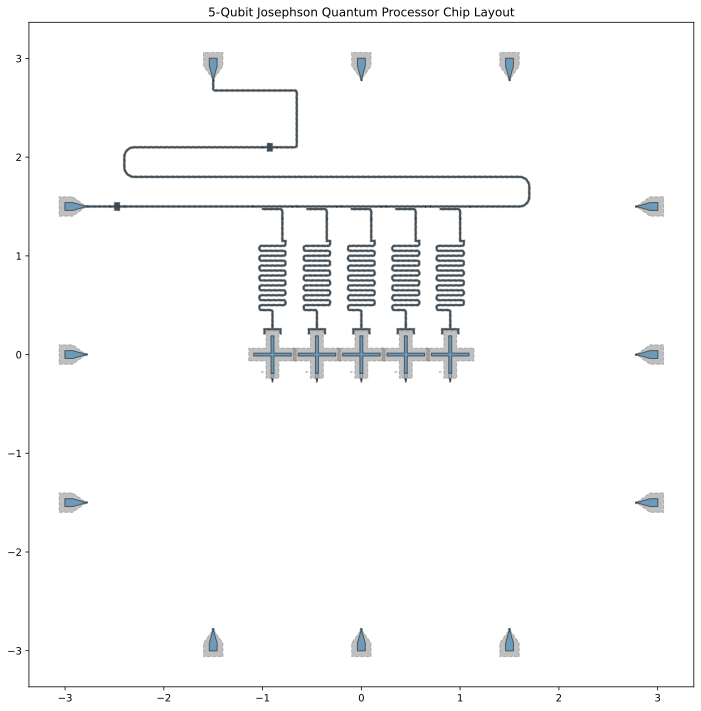

In [9]:
fig, ax = plt.subplots(figsize=(12, 12))
renderer = QMplRenderer(design, logger=design.logger)
renderer.render(ax)

ax.autoscale()
ax.set_aspect('equal')
plt.title("5-Qubit Josephson Quantum Processor Chip Layout")
plt.show()

## XY and Z control routing

### Paper control model (Fig. 1b)

- **XY line** — capacitively coupled microwaves → Bloch-sphere $X$/$Y$ rotations (paper: average single-qubit fidelity 99.92%).  
- **Z line** — inductively coupled DC/flux → qubit frequency; used for idle placement and the **fast adiabatic CZ** trajectory (~40 ns) via the $\|11\rangle$–$\|02\rangle$ avoided crossing.

Control wiring enters from chip-edge pads. In the experiment, reflections and fridge transfer functions on Z were carefully equalized (Supp. “Flattening the Z response”); geometrically we at least route each line with controlled bends and fillets.

### What this cell does

For each qubit we route:

| Signal | Start pin | Typical end |
|---|---|---|
| XY | `XY_pad_i` (`open`) | Assigned west/south/east/north launchpad |
| Z | `Q_i.flux_line` | Assigned launchpad on an unused edge |

`RouteFramed` with **turtle-style jog lists** (`start_jogged_extension`) keeps traces on a Manhattan path that skirts the qubit array and readout block. XY leads use a longer `start_straight` (200 µm) so the drive line clears the coupling pad before turning.

**Design checks for later:**

- Minimize XY–Z proximity near the qubit (crosstalk / spurious drive).  
- Avoid long parallel runs of adjacent Z lines (paper Z crosstalk ~1–2% before compensation).  
- Prefer smooth fillets; sharp corners radiate and complicate microwave calibration.


In [10]:
control_routes = [
    # Q0 XY -> LP_W2
    ('XY_pad_0', 'open', 'LP_W2', 'tie', 'XY_Line_0', Dict({})),
    # Q0 Z -> LP_W1
    ('Q0', 'flux_line', 'LP_W1', 'tie', 'Z_Line_0', Dict({})),
    # Q1 XY -> LP_S1
    ('XY_pad_1', 'open', 'LP_S1', 'tie', 'XY_Line_1', Dict({
        0: ['R', '50um'],
        1: ['L', '2000um'],
        2: ['R', '200um']

    })),
    # Q1 Z -> LP_E3
    ('Q1', 'flux_line', 'LP_S2', 'tie', 'Z_Line_1', Dict({
        0: ['L', '100um'],
        1: ['R', '2000um'],
        2:['L', '200um'],
        # 3:['R', '200um'],
    })),
    # Q2 XY -> LP_S2
    ('XY_pad_2', 'open', 'LP_S3', 'tie', 'XY_Line_2', Dict({
        0: ['R', '50um'],
        1: ['L', '1800um'],
        2: ['L', '500um']
    })),
    # Q2 Z -> LP_N2
    ('Q2', 'flux_line', 'LP_E1', 'tie', 'Z_Line_2', Dict({
       0: ['L', '100um'],
       1: ['R', '1600um'],
       2: ['L', '2500um'],
       3: ['L','100um'],
    })),
    # Q3 XY -> LP_S3
    ('XY_pad_3', 'open', 'LP_E2', 'tie', 'XY_Line_3', Dict({
        0: ['R', '50um'],
        1: ['L', '1400um'],
        2: ['L', '2100um'],
        3: ['L', '1200um'],
    })),
    # Q3 Z -> LP_N3
    ('Q3', 'flux_line', 'LP_E3', 'tie', 'Z_Line_3', Dict({
        0: ['L', '100um'],
        1: ['R', '1200um'],
        2: ['L', '1700um'],
        3: ['L', '800um']
    })),
    # Q4 XY -> LP_E2
    ('XY_pad_4', 'open', 'LP_N3', 'tie', 'XY_Line_4', Dict({
        0: ['R', '50um'],
        1: ['L', '1000um'],
        2: ['L', '1350um'],
        3: ['L', '3700um'],
        4: ['L', '400um'],
    })),
    # Q4 Z -> LP_E1
    ('Q4', 'flux_line', 'LP_N2', 'tie', 'Z_Line_4', Dict({
        0: ['L', '100um'],
        1: ['R', '800um'],
        2: ['L', '950um'],
        3: ['L', '3300um'],
        4: ['L', '400um'],
    })),
]

for start_comp, start_pin, end_comp, end_pin, route_name, turtle_steps in control_routes:
    route_options = dict(
        pin_inputs=dict(
            start_pin=dict(component=start_comp, pin=start_pin),
            end_pin=dict(component=end_comp, pin=end_pin)
        ),
        lead=dict(
            start_straight='100um',
            end_straight='50um',
            start_jogged_extension = turtle_steps,

        ),
        
        fillet='20um',
        step_size='0.05mm',

    )
    if "XY" in route_name:
        route_options['lead']['start_straight'] = '200um'
        
    RouteFramed(design, route_name, options=route_options)

print("XY and Z control lines successfully routed!")

XY and Z control lines successfully routed!


## Full-chip render

Final matplotlib view of the complete Metal design: five Xmons, staggered readout resonators, multiplexed feedline, and all XY/Z control routes to perimeter launchpads—layout analogue of paper Fig. 1a.


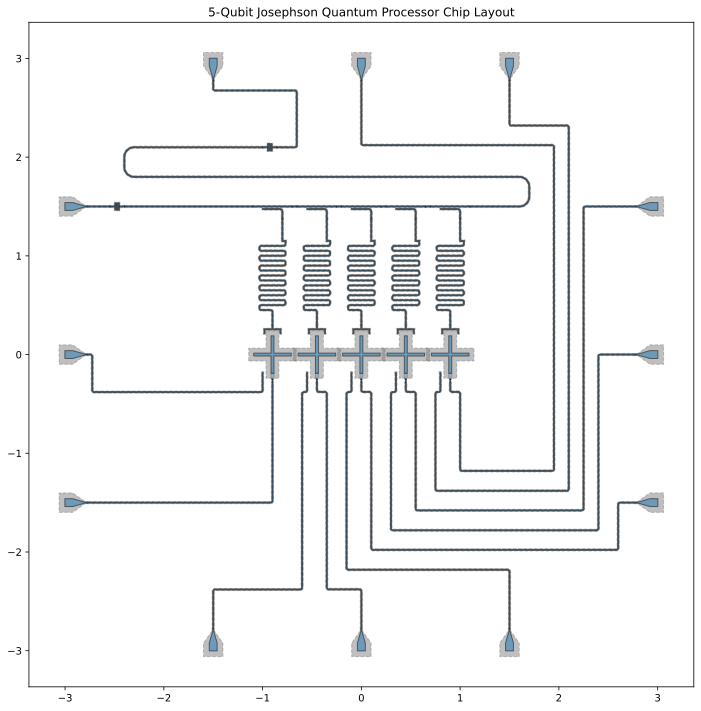

In [11]:
fig, ax = plt.subplots(figsize=(12, 12))
renderer = QMplRenderer(design, logger=design.logger)
renderer.render(ax)

ax.autoscale()
ax.set_aspect('equal')
plt.title("5-Qubit Josephson Quantum Processor Chip Layout")
plt.show()

## GDSII export for fabrication / EM

Export the planar design to `5QubitChip.gds` for mask prep or import into an EM solver. `short_segments_to_not_fillet = False` keeps short segments filletable so the GDS matches the on-screen CPW bends.

**Downstream workflow (not in this notebook, but implied by the paper):**

1. EM extract $C$, $L$, resonator $f_r$, couplings $g$, $g_r$, feedline $\kappa$.  
2. Choose Josephson energies / SQUID asymmetries for the alternating idle spectrum (~5.5 / 4.7 GHz class).  
3. Validate nearest-neighbour $g/2\pi \sim 30\,\mathrm{MHz}$ and idle ZZ.  
4. Close the loop on Purcell-limited $T_1$ vs readout speed.

The experimental processor reached single-qubit fidelities ~99.92% and CZ up to ~99.4%, at the surface-code threshold—targets that motivate this modular five-qubit layout.


In [ ]:
gds_renderer = design.renderers.gds
gds_renderer.options.short_segments_to_not_fillet = 'False'
gds_filename = '5QubitChip.gds'
gds_renderer.export_to_gds(gds_filename)

print(f"Layout exported to GDSII: {gds_filename}!")